In [17]:
# Load outputs from the previous notebook.
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/content")
INTERMEDIATE_FILE = DATA_DIR / "experiment_outputs.pkl"

with open(INTERMEDIATE_FILE, "rb") as file:
    experiment_outputs = pickle.load(file)

globals().update(experiment_outputs)

print("Loaded:", INTERMEDIATE_FILE)

Loaded: /content/experiment_outputs.pkl


## Cross-Experiment Comparison

The feature sets expand from voltage/history in A, to temperature in B, and operating context in C. All three experiments use the same 10,676 observations.


In [18]:
def get_silhouette(summary_df, model_name):
    return float(
        summary_df.loc[
            summary_df["model"] == model_name,
            "silhouette_score"
        ].iloc[0]
    )


cross_experiment_comparison = pd.DataFrame({
    "Experiment": ["A", "B", "C"],
    "Feature count": [
        len(base_feature_columns),
        len(experiment_b_feature_columns),
        len(experiment_c_feature_columns)
    ],
    "Observations": [
        len(model_df),
        len(experiment_b_model_df),
        len(experiment_c_df)
    ],
    "IF anomalies": [
        int(isolation_forest_results["is_anomalous"].sum()),
        int(if_results_b["is_anomalous"].sum()),
        int(if_results_c["is_anomalous"].sum())
    ],
    "OCSVM anomalies": [
        int(ocsvm_results["is_anomalous"].sum()),
        int(ocsvm_results_b["is_anomalous"].sum()),
        int(ocsvm_results_c["is_anomalous"].sum())
    ],
    "AE anomalies": [
        int(autoencoder_results["is_anomalous"].sum()),
        int(autoencoder_results_b["is_anomalous"].sum()),
        int(autoencoder_results_c["is_anomalous"].sum())
    ],
    "Consensus anomalies": [
        int(consensus_results["consensus_anomaly"].sum()),
        int(consensus_results_b["consensus_anomaly"].sum()),
        int(consensus_results_c["consensus_anomaly"].sum())
    ],
    "IF Silhouette": [
        get_silhouette(silhouette_summary, "Isolation Forest"),
        get_silhouette(silhouette_summary_b, "Isolation Forest"),
        get_silhouette(silhouette_summary_c, "Isolation Forest")
    ],
    "OCSVM Silhouette": [
        get_silhouette(silhouette_summary, "One-Class SVM"),
        get_silhouette(silhouette_summary_b, "One-Class SVM"),
        get_silhouette(silhouette_summary_c, "One-Class SVM")
    ],
    "AE Silhouette": [
        get_silhouette(silhouette_summary, "Autoencoder"),
        get_silhouette(silhouette_summary_b, "Autoencoder"),
        get_silhouette(silhouette_summary_c, "Autoencoder")
    ]
})

display(cross_experiment_comparison.round(4))

,Experiment,Feature count,Observations,IF anomalies,OCSVM anomalies,AE anomalies,Consensus anomalies,IF Silhouette,OCSVM Silhouette,AE Silhouette
0,A,5,10676,1710,537,534,300,0.5037,0.5296,0.6110
1,B,8,10676,1613,534,534,275,0.4018,0.4308,0.5007
2,C,12,10676,1634,532,534,297,0.4147,0.4422,0.4925


### Pairwise Detector Overlap

Pairwise Jaccard similarity measures the overlap between anomaly selections from the three detectors. It is used as an agreement measure, not as diagnostic accuracy.

In [19]:
# Compare pairwise agreement between detector anomaly flags.

def pairwise_jaccard(df_a, df_b, model_a, model_b, experiment):

    # Match the same cell-cycle observations before comparing flags.
    comparison = (
        df_a[["cycle", "cell", "is_anomalous"]]
        .rename(columns={"is_anomalous": "anomaly_a"})
        .merge(
            df_b[["cycle", "cell", "is_anomalous"]]
            .rename(columns={"is_anomalous": "anomaly_b"}),
            on=["cycle", "cell"],
            how="inner"
        )
    )

    intersection = (
        comparison["anomaly_a"] & comparison["anomaly_b"]
    ).sum()

    union = (
        comparison["anomaly_a"] | comparison["anomaly_b"]
    ).sum()

    # Jaccard is shared anomaly selections divided by their union.
    jaccard = intersection / union if union > 0 else np.nan

    return {
        "Experiment": experiment,
        "Model pair": f"{model_a} – {model_b}",
        "Intersection": int(intersection),
        "Union": int(union),
        "Jaccard": float(jaccard)
    }


experiment_results = {
    "A": {
        "IF": isolation_forest_results,
        "OCSVM": ocsvm_results,
        "AE": autoencoder_results
    },
    "B": {
        "IF": if_results_b,
        "OCSVM": ocsvm_results_b,
        "AE": autoencoder_results_b
    },
    "C": {
        "IF": if_results_c,
        "OCSVM": ocsvm_results_c,
        "AE": autoencoder_results_c
    }
}

pairwise_jaccard_rows = []

for experiment, results in experiment_results.items():
    for model_a, model_b in [
        ("IF", "OCSVM"),
        ("IF", "AE"),
        ("OCSVM", "AE")
    ]:
        pairwise_jaccard_rows.append(
            pairwise_jaccard(
                results[model_a],
                results[model_b],
                model_a,
                model_b,
                experiment
            )
        )

pairwise_jaccard_df = pd.DataFrame(pairwise_jaccard_rows)

display(pairwise_jaccard_df.round(4))

,Experiment,Model pair,Intersection,Union,Jaccard
0,A,IF – OCSVM,473,1774,0.2666
1,A,IF – AE,527,1717,0.3069
2,A,OCSVM – AE,302,769,0.3927
3,B,IF – OCSVM,467,1680,0.2780
4,B,IF – AE,529,1618,0.3269
5,B,OCSVM – AE,280,788,0.3553
6,C,IF – OCSVM,455,1711,0.2659
7,C,IF – AE,521,1647,0.3163
8,C,OCSVM – AE,302,764,0.3953


The pairwise results show partial overlap between detector selections, with the highest Jaccard similarity generally observed between OCSVM and the Autoencoder. This supports the use of strict consensus as a more selective agreement rule.

### Cross-Experiment Consensus Overlap

Overlap between strict-consensus observations is compared across Experiments A, B and C to assess how selections change with feature representation.

In [20]:
# Compare strict-consensus selections across feature experiments.

consensus_sets = {}

for experiment, results in {
    "A": consensus_results,
    "B": consensus_results_b,
    "C": consensus_results_c
}.items():

    selected = results.loc[
        results["consensus_anomaly"],
        ["cycle", "cell"]
    ]

    consensus_sets[experiment] = set(
        map(tuple, selected.to_numpy())
    )


consensus_overlap_rows = []

for experiment_a, experiment_b in [
    ("A", "B"),
    ("A", "C"),
    ("B", "C")
]:

    # Compare the same cell-cycle selections in both experiments.
    intersection = (
        consensus_sets[experiment_a]
        & consensus_sets[experiment_b]
    )

    union = (
        consensus_sets[experiment_a]
        | consensus_sets[experiment_b]
    )

    consensus_overlap_rows.append({
        "Experiment pair": f"{experiment_a} – {experiment_b}",
        "Intersection": len(intersection),
        "Union": len(union),
        "Jaccard": len(intersection) / len(union)
    })


consensus_overlap_df = pd.DataFrame(consensus_overlap_rows)

display(consensus_overlap_df.round(4))

triple_overlap = len(
    consensus_sets["A"]
    & consensus_sets["B"]
    & consensus_sets["C"]
)

print(
    "Strict-consensus observations shared by A, B and C:",
    triple_overlap
)

,Experiment pair,Intersection,Union,Jaccard
0,A – B,180,395,0.4557
1,A – C,183,414,0.4420
2,B – C,234,338,0.6923


Strict-consensus observations shared by A, B and C: 161


### Cross-Experiment Ranking Agreement

Spearman correlation compares the cell-level persistence rankings across Experiments A, B and C.

In [21]:
from scipy.stats import spearmanr

# Compare cell persistence rankings across experiments.

ranking_comparison = (
    consensus_cell_summary[["cell", "consensus_percentage"]]
    .rename(columns={"consensus_percentage": "A"})
    .merge(
        consensus_cell_summary_b[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "B"}),
        on="cell"
    )
    .merge(
        consensus_cell_summary_c[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "C"}),
        on="cell"
    )
)

spearman_rows = []

for experiment_a, experiment_b in [
    ("A", "B"),
    ("A", "C"),
    ("B", "C")
]:
    rho, _ = spearmanr(
        ranking_comparison[experiment_a],
        ranking_comparison[experiment_b]
    )

    spearman_rows.append({
        "Experiment pair": f"{experiment_a} – {experiment_b}",
        "Spearman rho": rho
    })

spearman_df = pd.DataFrame(spearman_rows)

display(spearman_df.round(4))

,Experiment pair,Spearman rho
0,A – B,0.5641
1,A – C,0.4527
2,B – C,0.8111


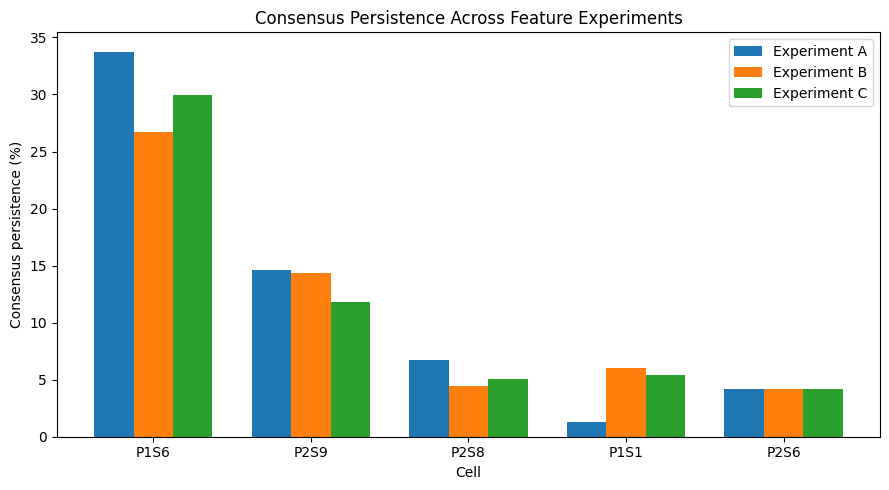

In [22]:
consensus_for_plot = (
    consensus_cell_summary[["cell", "consensus_percentage"]]
    .rename(columns={"consensus_percentage": "Experiment A"})
    .merge(
        consensus_cell_summary_b[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "Experiment B"}),
        on="cell"
    )
    .merge(
        consensus_cell_summary_c[["cell", "consensus_percentage"]]
        .rename(columns={"consensus_percentage": "Experiment C"}),
        on="cell"
    )
)

# Select the top cells using their mean consensus persistence across A, B and C.
consensus_for_plot["mean_consensus"] = consensus_for_plot[
    ["Experiment A", "Experiment B", "Experiment C"]
].mean(axis=1)

consensus_for_plot = consensus_for_plot.nlargest(5, "mean_consensus")

x_positions = np.arange(len(consensus_for_plot))
bar_width = 0.25

plt.figure(figsize=(9, 5))

for offset, experiment in zip(
    [-bar_width, 0, bar_width],
    ["Experiment A", "Experiment B", "Experiment C"]
):
    plt.bar(
        x_positions + offset,
        consensus_for_plot[experiment],
        width=bar_width,
        label=experiment
    )

plt.xticks(x_positions, consensus_for_plot["cell"])
plt.xlabel("Cell")
plt.ylabel("Consensus persistence (%)")
plt.title("Consensus Persistence Across Feature Experiments")
plt.legend()
plt.tight_layout()
plt.show()

Silhouette is not accuracy. The plot is a descriptive comparison because A/B/C use different feature spaces.


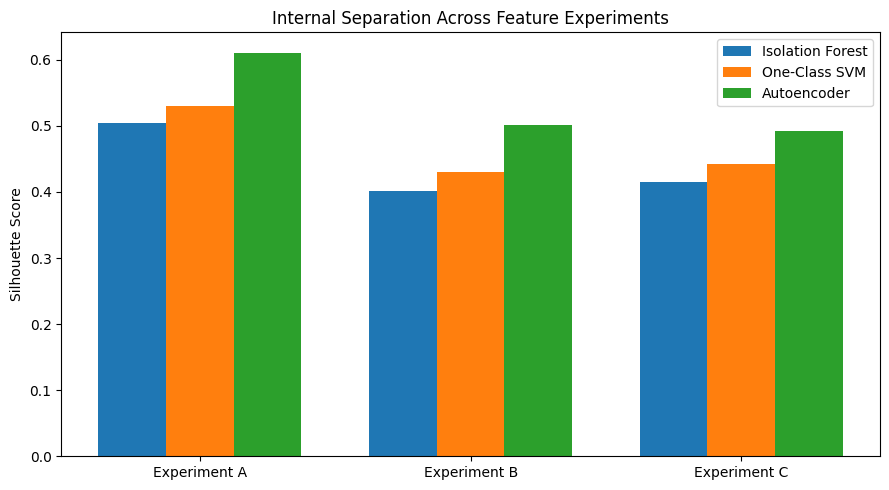

In [23]:
experiments = cross_experiment_comparison["Experiment"].map(
    {
        "A": "Experiment A",
        "B": "Experiment B",
        "C": "Experiment C"
    }
)

x_positions = np.arange(len(experiments))
bar_width = 0.25

plt.figure(figsize=(9, 5))

for offset, column, label in [
    (-bar_width, "IF Silhouette", "Isolation Forest"),
    (0, "OCSVM Silhouette", "One-Class SVM"),
    (bar_width, "AE Silhouette", "Autoencoder")
]:
    plt.bar(
        x_positions + offset,
        cross_experiment_comparison[column],
        width=bar_width,
        label=label
    )

plt.xticks(x_positions, experiments)
plt.ylabel("Silhouette Score")
plt.title("Internal Separation Across Feature Experiments")
plt.legend()
plt.tight_layout()
plt.show()

### Cross-Experiment Interpretation

P1S6 and P2S9 remained persistent anomaly candidates across all three feature sets. P1S6 consensus persistence was 33.76%, 26.75% and 29.94% in A/B/C; P2S9 persistence was 14.65%, 14.33% and 11.78%.


## Sensitivity and Robustness Analysis

Experiment C is tested using lower and higher alternatives around the main Isolation Forest, One-Class SVM and Autoencoder settings. These values test stability and are not claimed to be optimal.


In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM


def sensitivity_summary(labels, parameter_value, model_name):
    temp = experiment_c_df[["cycle", "cell"]].copy()
    temp["is_anomalous"] = labels

    cell_summary = (
        temp.groupby("cell")
        .agg(
            anomalous_cycles=("is_anomalous", "sum"),
            total_cycles=("cycle", "count")
        )
        .reset_index()
    )

    cell_summary["anomaly_percentage"] = (
        cell_summary["anomalous_cycles"]
        / cell_summary["total_cycles"]
        * 100
    )

    # Identify the leading persistent cell without pre-selecting a cell name.
    top_cell = cell_summary.sort_values(
        ["anomalous_cycles", "cell"],
        ascending=[False, True]
    ).iloc[0]

    return {
        "Model": model_name,
        "Parameter": parameter_value,
        "Total anomalies": int(np.sum(labels)),
        "Top persistent cell": top_cell["cell"],
        "Top cell cycles": int(top_cell["anomalous_cycles"]),
        "Top cell percent": float(top_cell["anomaly_percentage"])
    }


if_sensitivity_results = []

for contamination_value in ["auto", 0.03, 0.05, 0.08, 0.10]:

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination_value,
        random_state=42
    )

    labels = model.fit_predict(X_scaled_c) == -1

    if_sensitivity_results.append(
        sensitivity_summary(
            labels,
            contamination_value,
            "Isolation Forest"
        )
    )


ocsvm_sensitivity_results = []

for nu_value in [0.02, 0.05, 0.08, 0.10]:

    model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=nu_value
    )

    labels = model.fit_predict(X_scaled_c) == -1

    ocsvm_sensitivity_results.append(
        sensitivity_summary(
            labels,
            nu_value,
            "One-Class SVM"
        )
    )


ae_sensitivity_results = []

for percentile_value in [90, 95, 97.5, 99]:

    threshold = np.percentile(
        reconstruction_error_c,
        percentile_value
    )

    labels = reconstruction_error_c > threshold

    result = sensitivity_summary(
        labels,
        percentile_value,
        "Autoencoder"
    )

    result["Threshold"] = threshold
    ae_sensitivity_results.append(result)


if_sensitivity_df = pd.DataFrame(if_sensitivity_results)
ocsvm_sensitivity_df = pd.DataFrame(ocsvm_sensitivity_results)
ae_sensitivity_df = pd.DataFrame(ae_sensitivity_results)

print("Isolation Forest sensitivity")
display(if_sensitivity_df.round(2))

print("\nOne-Class SVM sensitivity")
display(ocsvm_sensitivity_df.round(2))

print("\nAutoencoder threshold sensitivity")
display(ae_sensitivity_df.round(4))

Isolation Forest sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent
0,Isolation Forest,auto,1634,P1S6,272,86.62
1,Isolation Forest,0.03,321,P1S6,166,52.87
2,Isolation Forest,0.05,534,P1S6,200,63.69
3,Isolation Forest,0.08,854,P1S6,231,73.57
4,Isolation Forest,0.1,1068,P1S6,248,78.98



One-Class SVM sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent
0,One-Class SVM,0.02,218,P1S6,39,12.42
1,One-Class SVM,0.05,532,P1S6,104,33.12
2,One-Class SVM,0.08,851,P1S6,162,51.59
3,One-Class SVM,0.10,1068,P1S6,201,64.01



Autoencoder threshold sensitivity


,Model,Parameter,Total anomalies,Top persistent cell,Top cell cycles,Top cell percent,Threshold
0,Autoencoder,90.0,1068,P1S6,238,75.7962,0.7805
1,Autoencoder,95.0,534,P1S6,223,71.0191,1.2245
2,Autoencoder,97.5,267,P1S6,194,61.7834,2.4352
3,Autoencoder,99.0,107,P1S6,89,28.3439,3.9150


### Sensitivity Analysis Interpretation

Anomaly counts changed across the tested settings, but P1S6 remained the top persistent cell for all three methods.

### Supplementary Robustness Check: Matched Anomaly Rate

This supplementary check uses Isolation Forest `contamination=0.05` with the main One-Class SVM and Autoencoder decisions. It examines the effect of more similar anomaly rates without replacing the main Experiment C result.


In [25]:
# Supplementary check: match the Isolation Forest anomaly rate to approximately 5%.
matched_if_c = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

matched_if_labels_c = matched_if_c.fit_predict(X_scaled_c) == -1

matched_rate_consensus_c = experiment_c_df[["cycle", "cell"]].copy()

matched_rate_consensus_c["if_anomalous_5_percent"] = matched_if_labels_c
matched_rate_consensus_c["ocsvm_anomalous"] = ocsvm_results_c["is_anomalous"].to_numpy()
matched_rate_consensus_c["autoencoder_anomalous"] = autoencoder_results_c["is_anomalous"].to_numpy()

matched_rate_consensus_c["consensus_anomaly"] = (
    matched_rate_consensus_c[
        [
            "if_anomalous_5_percent",
            "ocsvm_anomalous",
            "autoencoder_anomalous"
        ]
    ].all(axis=1)
)

matched_rate_persistence_c = (
    matched_rate_consensus_c
    .groupby("cell")
    .agg(
        consensus_anomalous_cycles=("consensus_anomaly", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

matched_rate_persistence_c["consensus_percentage"] = (
    matched_rate_persistence_c["consensus_anomalous_cycles"]
    / matched_rate_persistence_c["total_cycles"]
    * 100
)

matched_rate_comparison_c = (
    consensus_cell_summary_c[
        [
            "cell",
            "consensus_anomalous_cycles",
            "consensus_percentage"
        ]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "main_consensus_cycles",
        "consensus_percentage": "main_consensus_percent"
    })
    .merge(
        matched_rate_persistence_c,
        on="cell",
        how="outer"
    )
    .sort_values(
        ["consensus_anomalous_cycles", "main_consensus_cycles"],
        ascending=False
    )
)

print("Main Experiment C model anomaly rates (%):")
print("Isolation Forest:", round(if_results_c["is_anomalous"].mean() * 100, 2))
print("One-Class SVM:", round(ocsvm_results_c["is_anomalous"].mean() * 100, 2))
print("Autoencoder:", round(autoencoder_results_c["is_anomalous"].mean() * 100, 2))

print("\nMain versus supplementary consensus persistence:")

display(
    matched_rate_comparison_c
    .head(15)
    .round(2)
)

Main Experiment C model anomaly rates (%):
Isolation Forest: 15.31
One-Class SVM: 4.98
Autoencoder: 5.0

Main versus supplementary consensus persistence:


,cell,main_consensus_cycles,main_consensus_percent,consensus_anomalous_cycles,total_cycles,consensus_percentage
7,P1S6,94,29.94,80,314,25.48
22,P2S9,37,11.78,31,314,9.87
21,P2S8,16,5.10,11,314,3.50
19,P2S6,13,4.14,8,314,2.55
0,P1S1,17,5.41,7,314,2.23
30,P3S6,8,2.55,7,314,2.23
33,P3S9,7,2.23,7,314,2.23
28,P3S4,8,2.55,6,314,1.91
24,P3S10,7,2.23,6,314,1.91
26,P3S2,7,2.23,6,314,1.91


### Supplementary Baseline Comparison

Local Outlier Factor (LOF) is used as a supplementary baseline on Experiment C. Its anomaly rate is matched to the Experiment C strict-consensus rate so that the comparison uses a similar number of selected observations.

In [26]:
from sklearn.neighbors import LocalOutlierFactor

# Match the LOF anomaly rate to the Experiment C consensus rate.
consensus_rate_c = consensus_results_c["consensus_anomaly"].mean()

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=consensus_rate_c
)

lof_labels_c = lof_model.fit_predict(X_scaled_c) == -1

lof_results_c = experiment_c_df[["cycle", "cell"]].copy()
lof_results_c["lof_anomalous"] = lof_labels_c
lof_results_c["consensus_anomaly"] = (
    consensus_results_c["consensus_anomaly"].to_numpy()
)

# Compare observation-level selections.
intersection = (
    lof_results_c["lof_anomalous"]
    & lof_results_c["consensus_anomaly"]
).sum()

union = (
    lof_results_c["lof_anomalous"]
    | lof_results_c["consensus_anomaly"]
).sum()

lof_jaccard = intersection / union if union > 0 else np.nan

print("LOF anomalies:", int(lof_results_c["lof_anomalous"].sum()))
print(
    "Experiment C consensus anomalies:",
    int(lof_results_c["consensus_anomaly"].sum())
)
print("Intersection:", int(intersection))
print("Union:", int(union))
print("Jaccard:", round(lof_jaccard, 4))


# Compare cell-level persistence.
lof_cell_summary = (
    lof_results_c
    .groupby("cell")
    .agg(
        lof_anomalous_cycles=("lof_anomalous", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

lof_cell_summary["lof_percentage"] = (
    lof_cell_summary["lof_anomalous_cycles"]
    / lof_cell_summary["total_cycles"]
    * 100
)

lof_persistence_comparison = (
    consensus_cell_summary_c[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .merge(
        lof_cell_summary[
            ["cell", "lof_anomalous_cycles", "lof_percentage"]
        ],
        on="cell"
    )
)

lof_rho, _ = spearmanr(
    lof_persistence_comparison["consensus_percentage"],
    lof_persistence_comparison["lof_percentage"]
)

print(
    "\nCell-persistence ranking Spearman rho:",
    round(lof_rho, 4)
)

display(
    lof_persistence_comparison
    .sort_values(
        ["consensus_anomalous_cycles", "lof_anomalous_cycles"],
        ascending=False
    )
    .head(15)
    .round(2)
)

LOF anomalies: 297
Experiment C consensus anomalies: 297
Intersection: 92
Union: 502
Jaccard: 0.1833

Cell-persistence ranking Spearman rho: 0.4383


,cell,consensus_anomalous_cycles,consensus_percentage,lof_anomalous_cycles,lof_percentage
7,P1S6,94,29.94,20,6.37
22,P2S9,37,11.78,31,9.87
0,P1S1,17,5.41,15,4.78
21,P2S8,16,5.10,19,6.05
19,P2S6,13,4.14,53,16.88
8,P1S7,9,2.87,11,3.50
28,P3S4,8,2.55,5,1.59
30,P3S6,8,2.55,4,1.27
24,P3S10,7,2.23,7,2.23
33,P3S9,7,2.23,6,1.91


The matched-rate LOF baseline selected 297 observations, equal to the Experiment C strict-consensus count. Observation-level overlap was limited (Jaccard = 0.1833), while cell-level persistence rankings showed a positive association (Spearman rho = 0.4383). This comparison describes agreement only and does not indicate diagnostic accuracy.

## Maintenance-Priority Ranking

The maintenance-priority score is the mean consensus persistence across A/B/C. Because all cells use the same 314-cycle denominator, integer consensus counts are used for ordering to avoid floating-point tie differences. Experiment C is used only as a secondary tie-break. Exact ties share the same priority group. The ranking identifies inspection priorities, not failure probabilities.


In [27]:
# Build the final maintenance-priority table
# from consensus persistence across Experiments A, B and C.

priority_a = (
    consensus_cell_summary[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "A_consensus_cycles",
        "consensus_percentage": "A_consensus_percent"
    })
)

priority_b = (
    consensus_cell_summary_b[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "B_consensus_cycles",
        "consensus_percentage": "B_consensus_percent"
    })
)

priority_c = (
    consensus_cell_summary_c[
        ["cell", "consensus_anomalous_cycles", "consensus_percentage"]
    ]
    .rename(columns={
        "consensus_anomalous_cycles": "C_consensus_cycles",
        "consensus_percentage": "C_consensus_percent"
    })
)

maintenance_priority = (
    priority_a
    .merge(priority_b, on="cell", how="outer")
    .merge(priority_c, on="cell", how="outer")
    .fillna(0)
)

# Use consensus counts for ranking because all cells have the same denominator.
maintenance_priority["total_consensus_cycles"] = (
    maintenance_priority["A_consensus_cycles"]
    + maintenance_priority["B_consensus_cycles"]
    + maintenance_priority["C_consensus_cycles"]
)

# Final priority is the mean persistence across A, B and C.
maintenance_priority["mean_consensus_percent"] = (
    maintenance_priority[
        [
            "A_consensus_percent",
            "B_consensus_percent",
            "C_consensus_percent"
        ]
    ].mean(axis=1)
)

# Rank by overall persistence, then use Experiment C as the tie-break.
maintenance_priority = (
    maintenance_priority
    .sort_values(
        [
            "total_consensus_cycles",
            "C_consensus_cycles",
            "cell"
        ],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

# Exact ties share the same priority group.
new_group = (
    maintenance_priority[
        ["total_consensus_cycles", "C_consensus_cycles"]
    ]
    .ne(
        maintenance_priority[
            ["total_consensus_cycles", "C_consensus_cycles"]
        ].shift()
    )
    .any(axis=1)
)

maintenance_priority["priority_group"] = new_group.cumsum()

maintenance_priority = maintenance_priority[
    [
        "priority_group",
        "cell",
        "A_consensus_cycles",
        "A_consensus_percent",
        "B_consensus_cycles",
        "B_consensus_percent",
        "C_consensus_cycles",
        "C_consensus_percent",
        "mean_consensus_percent"
    ]
]

display(
    maintenance_priority
    .head(15)
    .round(6)
)

,priority_group,cell,A_consensus_cycles,A_consensus_percent,B_consensus_cycles,B_consensus_percent,C_consensus_cycles,C_consensus_percent,mean_consensus_percent
0,1,P1S6,106,33.757962,84,26.751592,94,29.936306,30.148620
1,2,P2S9,46,14.649682,45,14.331210,37,11.783439,13.588110
2,3,P2S8,21,6.687898,14,4.458599,16,5.095541,5.414013
3,4,P1S1,4,1.273885,19,6.050955,17,5.414013,4.246285
4,5,P2S6,13,4.140127,13,4.140127,13,4.140127,4.140127
5,6,P1S7,4,1.273885,9,2.866242,9,2.866242,2.335456
6,7,P3S12,9,2.866242,7,2.229299,6,1.910828,2.335456
7,8,P1S12,8,2.547771,5,1.592357,5,1.592357,1.910828
8,9,P3S6,2,0.636943,7,2.229299,8,2.547771,1.804671
9,10,P3S10,4,1.273885,4,1.273885,7,2.229299,1.592357


### Final Ranking Validation
The following checks confirm the number of retained cells, exact priority ties and the leading five maintenance-priority candidates.

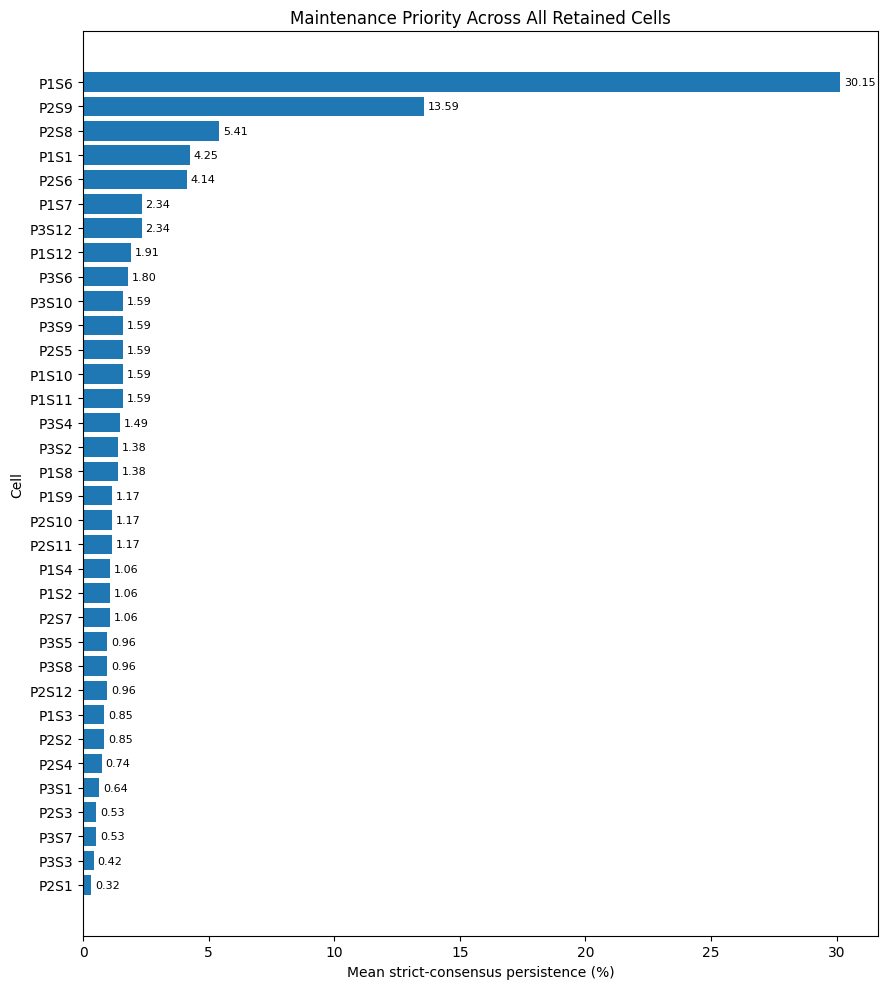

In [28]:
# Plot the final maintenance-priority scores for all retained cells.

priority_plot = maintenance_priority.copy()

plt.figure(figsize=(9, 10))

bars = plt.barh(
    priority_plot["cell"],
    priority_plot["mean_consensus_percent"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean strict-consensus persistence (%)")
plt.ylabel("Cell")
plt.title("Maintenance Priority Across All Retained Cells")

for bar, value in zip(
    bars,
    priority_plot["mean_consensus_percent"]
):
    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "figure_5_6_maintenance_priority_all_cells.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Final checks for the maintenance-priority ranking.

print("Number of retained cells:", len(maintenance_priority))
print("Number of priority groups:", maintenance_priority["priority_group"].nunique())

print("\nExact tied priority groups:")
display(
    maintenance_priority[
        maintenance_priority.duplicated("priority_group", keep=False)
    ][
        [
            "priority_group",
            "cell",
            "A_consensus_cycles",
            "B_consensus_cycles",
            "C_consensus_cycles",
            "mean_consensus_percent"
        ]
    ].round(6)
)

print("\nTop five cells:")
display(
    maintenance_priority[
        [
            "priority_group",
            "cell",
            "mean_consensus_percent"
        ]
    ].head(5).round(6)
)

Number of retained cells: 34
Number of priority groups: 31

Exact tied priority groups:


,priority_group,cell,A_consensus_cycles,B_consensus_cycles,C_consensus_cycles,mean_consensus_percent
9,10,P3S10,4,4,7,1.592357
10,10,P3S9,4,4,7,1.592357
17,17,P1S9,5,2,4,1.167728
18,17,P2S10,4,3,4,1.167728
23,22,P3S5,4,2,3,0.955414
24,22,P3S8,3,3,3,0.955414



Top five cells:


,priority_group,cell,mean_consensus_percent
0,1,P1S6,30.148620
1,2,P2S9,13.588110
2,3,P2S8,5.414013
3,4,P1S1,4.246285
4,5,P2S6,4.140127


### Feature Profiles of the Highest-Priority Candidates

The table shows the strongest average standardised Experiment C feature departures for the top candidates. These are descriptive profiles, not exact model attribution or evidence of degradation.


In [30]:
top_priority_cells = maintenance_priority.head(3)["cell"].tolist()

candidate_feature_profiles = X_scaled_c.copy()
candidate_feature_profiles["cell"] = experiment_c_df["cell"].to_numpy()

candidate_feature_profiles = (
    candidate_feature_profiles[
        candidate_feature_profiles["cell"].isin(top_priority_cells)
    ]
    .groupby("cell")[experiment_c_feature_columns]
    .mean()
)

profile_records = []

for cell in top_priority_cells:
    profile = candidate_feature_profiles.loc[cell]

    # Show the five largest average departures from the overall standardized mean.
    for feature in profile.abs().nlargest(5).index:

        direction = (
            "above overall mean"
            if profile[feature] > 0
            else "below overall mean"
        )

        profile_records.append({
            "cell": cell,
            "feature": feature,
            "mean_standardized_value": profile[feature],
            "direction": direction
        })

candidate_profile_summary = pd.DataFrame(profile_records)

display(candidate_profile_summary.round(3))

,cell,feature,mean_standardized_value,direction
0,P1S6,lowest_voltage_frequency,4.187,above overall mean
1,P1S6,load_response_difference,2.570,above overall mean
2,P1S6,high_load_voltage_deviation,2.029,above overall mean
3,P1S6,voltage_deviation,1.580,above overall mean
4,P1S6,low_soc_voltage_deviation,0.975,above overall mean
5,P2S9,lowest_voltage_frequency,0.616,above overall mean
6,P2S9,temperature_deviation,-0.326,below overall mean
7,P2S9,temperature_mean,0.296,above overall mean
8,P2S9,temperature_max,0.281,above overall mean
9,P2S9,voltage_deviation,0.247,above overall mean


### Maintenance-Priority Interpretation

The ranking begins with P1S6 (30.15%), P2S9 (13.59%), P2S8 (5.41%), P1S1 (4.25%) and P2S6 (4.14%). These percentages describe consensus persistence, not failure probability.


## Cost and Manufacturing-Carbon Scenario

The scenario calculations are separate from the anomaly scores. Manufacturing-carbon intensity values are based on Aichberger and Jungmeier (2020), and the pack-cost benchmark is based on Škegro et al. (2026). Intervention fractions of 10%, 20% and 30% are illustrative assumptions used in this dissertation.

In [31]:
# Calculate the conditional carbon and cost scenarios.

manufacturing_intensity = [70, 120, 175]
intervention_fractions = [0.10, 0.20, 0.30]

carbon_rows = []

for intensity in manufacturing_intensity:
    row = {"Manufacturing intensity": intensity}

    for fraction in intervention_fractions:
        row[f"{int(fraction * 100)}% intervention"] = (
            intensity * (1 - fraction)
        )

    carbon_rows.append(row)

carbon_scenario = pd.DataFrame(carbon_rows)

display(carbon_scenario)


pack_cost = 98.37

cost_rows = []

for fraction in intervention_fractions:
    cost_rows.append({
        "Intervention fraction": f"{int(fraction * 100)}%",
        "Pack benchmark": pack_cost,
        "Targeted proportional cost": pack_cost * fraction,
        "Gross difference": pack_cost * (1 - fraction)
    })

cost_scenario = pd.DataFrame(cost_rows)

display(cost_scenario.round(3))


central_intensity = 120
central_fraction = 0.20

carbon_break_even = central_intensity * (1 - central_fraction)
cost_break_even = pack_cost * (1 - central_fraction)

print("Central carbon break-even:", carbon_break_even, "kg CO2-eq/kWh")
print("Central cost break-even:", round(cost_break_even, 3), "€/kWh")

,Manufacturing intensity,10% intervention,20% intervention,30% intervention
0,70,63.0,56.0,49.0
1,120,108.0,96.0,84.0
2,175,157.5,140.0,122.5


,Intervention fraction,Pack benchmark,Targeted proportional cost,Gross difference
0,10%,98.37,9.837,88.533
1,20%,98.37,19.674,78.696
2,30%,98.37,29.511,68.859


Central carbon break-even: 96.0 kg CO2-eq/kWh
Central cost break-even: 78.696 €/kWh


## Methodological Limitations

There are no ground-truth physical fault labels or external validation across other packs, vehicles or chemistries. The analysis uses one battery-pack dataset and focuses on retained WLTP segments rather than separately modelling charging, balancing or other modes.

The full prepared unlabeled dataset is used in-sample. The Autoencoder is trained and scored on the same data, so some unusual patterns may also be learned during training. Results depend on model settings and thresholds. Five partial WLTP segments were removed using a coverage-quality rule, and the operating-context features use relative within-cycle quartiles.
